# Gallery Reproduction With `hawkes_tools`

This notebook is a gallery-style tour of the standalone `hawkes_tools` API. Each section keeps a compact, reproducible example that can be rerun from the local package.

Dataset-backed examples load vendored public datasets through `hawkes_tools.datasets`; simulation examples use the gallery sizes and parameters unless the standalone API lacks the corresponding non-Hawkes learner.


## Gallery

| # | Example | API area | Description |
| --- | --- | --- | --- |
| 1 | Fit Hawkes on finance data | Conditional-law estimation and Bund data | Loads the vendored Bund dataset and estimates signed conditional-law kernel norms on ragged multistream events. |
| 2 | Cox regression data simulation | Survival simulation | Simulates proportional-hazards survival data and visualizes observed failures versus censoring. |
| 3 | Binary classification with logistic regression | Logistic learner and Adult data | Fits logistic regression on vendored Adult data and plots the test ROC curve. |
| 4 | Inhomogeneous Poisson process simulation | Time functions and point-process plotting | Builds a sinusoidal `TimeFunction`, simulates an inhomogeneous Poisson process, and plots the event history. |
| 5 | Fit sparse and low rank adjacency matrix with Hawkes ADM4 | Hawkes ADM4 | Simulates block-structured exponential Hawkes events and estimates a sparse/low-rank adjacency matrix. |
| 6 | Comparison of solvers for Poisson regression | Poisson GLM, simulators, solver history | Compares GD, AGD, SVRG, and BFGS objectives on a synthetic Poisson regression problem. |
| 7 | Fit Hawkes with asynchronous causality | Sum-Gaussian Hawkes kernels | Recovers delayed cross-excitation patterns with a sum-of-Gaussians Hawkes learner. |
| 8 | Fit Hawkes power law kernels | Conditional-law estimation and power-law kernels | Simulates heavy-tailed power-law Hawkes kernels and inspects conditional-law recovery on a log scale. |
| 9 | Fit Hawkes random kernels | EM and time-function kernels | Uses EM to estimate non-parametric kernels from a Hawkes process with exponential, power-law, and time-function components. |
| 10 | Examples of proximal operators | Public prox operators | Shows the effect of common prox operators on the same random vector. |
| 11 | Precision vs speed tradeoff | Logistic learner and Adult data | Compares float32 and float64 logistic optimization paths on the Adult design matrix. |
| 12 | Linear models data simulation | Linear, logistic, and Poisson simulators | Generates matching two-dimensional linear, logistic, and Poisson regression datasets. |
| 13 | Hawkes simulation with exotic kernels | Time-function kernels and QQ plots | Simulates custom signed time-function kernels and checks event residuals with QQ diagnostics. |
| 14 | Fit Hawkes kernel norms using cumulants | Cumulant matching | Estimates Hawkes kernel norms from cumulants on a synthetic exponential Hawkes process. |
| 15 | Automatic step choice | Sparse logistic GLM, elastic-net prox, and SVRG | Exercises sparse logistic optimization with elastic-net regularization and recorded solver history. |
| 16 | Robust linear model example | Robust learner and support metrics | Fits robust linear regression with sparse sample intercepts and reports outlier-support metrics. |
| 17 | Asynchronous stochastic solver | Sparse logistic GLM plus SVRG/SAGA | Compares stochastic variance-reduced solver traces through the n-threads-compatible learner surface. |
| 18 | Logistic regression comparison | Logistic learner and Adult data | Compares BFGS and GD logistic fits on vendored Adult data with ROC and timing views. |
| 19 | Simulate Hawkes process with non constant baseline | Time functions and exponential kernels | Simulates an exponential Hawkes process driven by a cyclic time-varying baseline. |
| 20 | Fit exotic Hawkes kernels | Basis kernels and time-function kernels | Fits basis kernels against synthetic smooth time-function Hawkes kernels. |
| 21 | Hawkes process with non constant baseline | Sum-exponential kernels | Fits a periodic-baseline sum-exponential Hawkes model and plots baselines with kernels. |
| 22 | Linear regression in two dimensions | Linear learner and Abalone data | Fits a two-feature linear regression model on vendored Abalone data and renders several 3D views. |
| 23 | Plot estimated intensity and assess goodness of fit | Sum-exponential learners and QQ plots | Overlays fitted and simulated intensities, then checks compensator residuals with QQ diagnostics. |
| 24 | Generalized linear models solver convergence | GLM models and solver/prox history | Tracks solver convergence behavior for standalone GLM model/prox combinations. |
| 25 | ConvSCCS cross validation on simulated longitudinal features | SCCS simulator and ConvSCCS learner | Simulates longitudinal exposure effects and plots fitted relative-incidence curves with confidence bands. |
| 26 | RKHS Hawkes estimator with alpha/Erlang kernel | RKHS non-parametric Hawkes estimation | Simulates an alpha-type kernel, overlays true and RKHS-estimated kernels, and plots the first recovered basis functions. |


## Port Map Status

Survival, robust-model, and metric modules now have pure-Python implementations used by the gallery examples below. SVRG and SAGA use stochastic variance-reduced update math with sparse mini-batches; true asynchronous atomic worker backends are outside this package's pure-Python scope.


In [1]:
from pathlib import Path
from time import perf_counter
from itertools import product
import os
import sys
import warnings

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(path for path in candidates if (path / "src" / "hawkes_tools").exists())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
from scipy import sparse as scipy_sparse

from hawkes_tools.base import TimeFunction
from hawkes_tools.datasets import fetch_dataset, fetch_hawkes_bund_data, list_datasets
from hawkes_tools.linear_model import (
    LinearRegression,
    LogisticRegression,
    ModelLinReg,
    ModelLogReg,
    ModelPoisReg,
    PoissonRegression,
    SimuLinReg,
    SimuLogReg,
    SimuPoisReg,
    weights_sparse_gauss,
)
from hawkes_tools.metrics import support_fdp, support_recall
from hawkes_tools.robust import RobustLinearRegression, features_normal_cov_toeplitz, std_iqr
from hawkes_tools.survival import ConvSCCS, SimuCoxReg, SimuSCCS
from hawkes_tools.survival.simu_sccs import CustomEffects
from hawkes_tools.hawkes import (
    HawkesADM4,
    HawkesBasisKernels,
    HawkesConditionalLaw,
    HawkesCumulantMatching,
    HawkesEM,
    HawkesKernel0,
    HawkesKernelExp,
    HawkesKernelPowerLaw,
    HawkesKernelTimeFunc,
    RKHSHawkes,
    HawkesSumExpKern,
    HawkesSumGaussians,
    SimuHawkes,
    SimuHawkesExpKernels,
    SimuHawkesMulti,
    SimuHawkesSumExpKernels,
    SimuInhomogeneousPoisson,
)
from hawkes_tools.plot import (
    plot_basis_kernels,
    plot_estimated_intensity,
    plot_hawkes_baseline_and_kernels,
    plot_hawkes_kernel_norms,
    plot_hawkes_kernels,
    plot_history,
    plot_point_process,
    qq_plots,
)
from hawkes_tools.prox import (
    ProxBinarsity,
    ProxElasticNet,
    ProxEquality,
    ProxGroupL1,
    ProxL1,
    ProxL1w,
    ProxL2Sq,
    ProxPositive,
    ProxSlope,
    ProxTV,
    ProxZero,
)
from hawkes_tools.solver import AGD, BFGS, GD, SAGA, SDCA, SVRG

DATA_HOME = os.environ.get("HAWKES_TOOLS_DATASETS")
DATASET_MANIFEST = list_datasets()
results = []


def fast_sparse_random_csr(n_rows, n_cols, density, seed):
    nnz = int(round(n_rows * n_cols * density))
    rng = np.random.default_rng(seed)
    flat = rng.choice(n_rows * n_cols, size=nnz, replace=False)
    rows = (flat // n_cols).astype(np.int32, copy=False)
    cols = (flat % n_cols).astype(np.int32, copy=False)
    data = rng.random(nnz)
    return scipy_sparse.csr_matrix((data, (rows, cols)), shape=(n_rows, n_cols))


def show_fig(fig):
    if fig is not None:
        display(fig)
        plt.close(fig)


def record(name, **values):
    clean = {}
    for key, value in values.items():
        if isinstance(value, np.ndarray):
            clean[key] = np.round(value.astype(float), 6).tolist()
        elif isinstance(value, tuple):
            clean[key] = value
        else:
            clean[key] = value
    results.append({"example": name, **clean})
    print({"example": name, **clean})


## 1. Fit Hawkes On Finance Data

The original page uses `fetch_hawkes_bund_data`. This standalone notebook loads the vendored Bund dataset through `hawkes_tools.datasets` and uses the source-reviewed conditional-law lag/support settings. The data is ragged rather than rectangular: 20 daily realizations, each with 4 timestamp streams (`P_u`, `P_d`, `T_a`, `T_b`) and a different number of events per stream. Positive signed kernel norms are plotted in blue.


{'example': 'finance_conditional_law', 'data_source': 'vendored bundled dataset hawkes/bund/bund.npz', 'realizations': 20, 'nodes': 4, 'ragged_shape': '[20][4][variable events]', 'events': 859467, 'events_per_node': {'P_u': 119302, 'P_d': 119346, 'T_a': 288059, 'T_b': 332760}, 'norms_shape': (4, 4)}


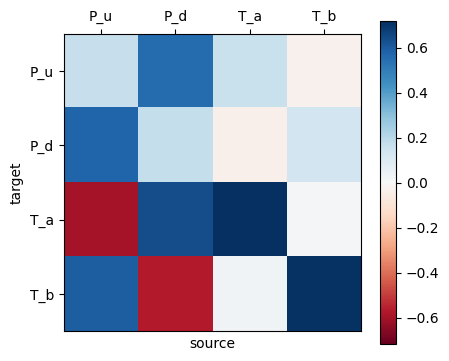

In [3]:
timestamps_list = fetch_hawkes_bund_data(data_home=DATA_HOME)
node_names = ["P_u", "P_d", "T_a", "T_b"]
realization_count = len(timestamps_list)
node_count = len(timestamps_list[0])
events_per_node = [int(sum(len(realization[node]) for realization in timestamps_list)) for node in range(node_count)]
event_count = int(sum(events_per_node))
kernel_discretization = np.hstack((0, np.logspace(-5, 0, 50)))
learner = HawkesConditionalLaw(
    claw_method="log",
    delta_lag=0.1,
    min_lag=5e-4,
    max_lag=500,
    quad_method="log",
    n_quad=10,
    min_support=1e-4,
    max_support=1,
    n_threads=4,
).fit(timestamps_list)
fig = plot_hawkes_kernel_norms(
    learner,
    node_names=node_names,
    pcolor_kwargs={"cmap": "RdBu"},
    show=False,
)
record(
    "finance_conditional_law",
    data_source="vendored bundled dataset hawkes/bund/bund.npz",
    realizations=realization_count,
    nodes=node_count,
    ragged_shape=f"[{realization_count}][{node_count}][variable events]",
    events=event_count,
    events_per_node=dict(zip(node_names, events_per_node)),
    norms_shape=learner.get_kernel_norms().shape,
)
show_fig(fig)


## 4. Inhomogeneous Poisson Process Simulation

Direct standalone reproduction of the TimeFunction-driven inhomogeneous Poisson example.


{'example': 'inhomogeneous_poisson', 'jumps': 41}


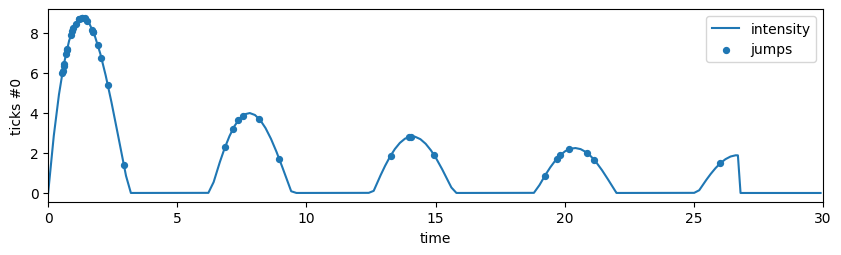

In [4]:
run_time = 30
T = np.arange((run_time * 0.9) * 5, dtype=float) / 5
Y = np.maximum(15 * np.sin(T) / (np.sqrt(T + 1) + 0.1 * T), 0.001)
time_function = TimeFunction((T, Y), dt=0.01)
process = SimuInhomogeneousPoisson([time_function], end_time=run_time, verbose=False)
process.track_intensity(0.1)
process.simulate()
fig = plot_point_process(process, show=False)
record("inhomogeneous_poisson", jumps=process.n_total_jumps)
show_fig(fig)


## 5. Hawkes ADM4 Sparse/Low-Rank Fit

Original-scale simulation-to-learner reproduction of the ADM4 example.


{'example': 'adm4', 'baseline': [0.029456, 0.030518, 0.031557, 0.029651, 0.031178, 0.02953], 'adjacency_shape': (6, 6), 'realizations': 5}


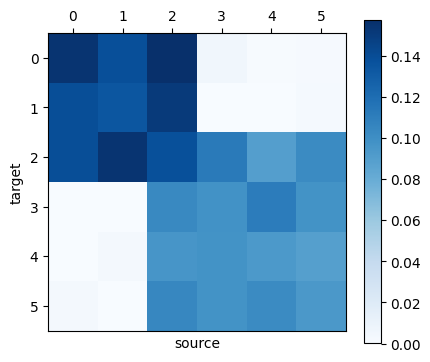

In [5]:
end_time = 10000
n_realizations = 5
decay = 3.0
baseline = np.ones(6) * 0.03
adjacency = np.zeros((6, 6))
adjacency[2:, 2:] = np.ones((4, 4)) * 0.1
adjacency[:3, :3] = np.ones((3, 3)) * 0.15
base = SimuHawkesExpKernels(
    adjacency=adjacency,
    decays=decay,
    baseline=baseline,
    end_time=end_time,
    seed=1039,
    verbose=False,
)
multi = SimuHawkesMulti(base, n_simulations=n_realizations, n_threads=4)
multi.end_time = [(i + 1) / n_realizations * end_time for i in range(n_realizations)]
multi.simulate()
learner = HawkesADM4(decay=decay, verbose=False).fit(multi.timestamps, end_times=multi.end_time)
fig = plot_hawkes_kernel_norms(learner, show=False)
record("adm4", baseline=learner.baseline, adjacency_shape=learner.adjacency.shape, realizations=n_realizations)
show_fig(fig)


## 7. Hawkes With Asynchronous Causality

Original-scale reproduction of the `HawkesSumGaussians` example with exponential, power-law, zero, and time-function kernels.


{'example': 'sum_gaussians', 'realizations': 10, 'jumps': 13214, 'sim_elapsed': 0.21831579999707174, 'fit_elapsed': 0.6477928000022075, 'norms_shape': (2, 2)}


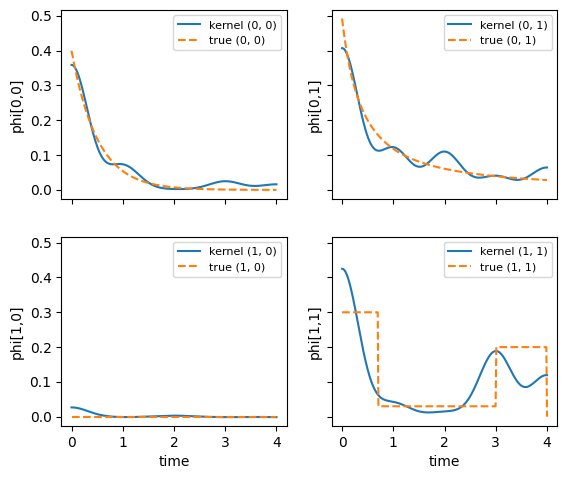

In [6]:
end_time = 1000
n_realizations = 10
n_gaussians = 5
kernel_timefunction = HawkesKernelTimeFunc(
    t_values=np.array([0.0, 0.7, 2.5, 3.0, 4.0]),
    y_values=np.array([0.3, 0.03, 0.03, 0.2, 0.0]),
)
kernels = [
    [HawkesKernelExp(0.2, 2.0), HawkesKernelPowerLaw(0.2, 0.5, 1.3)],
    [HawkesKernel0(), kernel_timefunction],
]
hawkes = SimuHawkes(baseline=[0.5, 0.2], kernels=kernels, end_time=end_time, verbose=False, seed=1039)
t0 = perf_counter()
multi = SimuHawkesMulti(hawkes, n_simulations=n_realizations, n_threads=4).simulate()
sim_elapsed = perf_counter() - t0
t0 = perf_counter()
learner = HawkesSumGaussians(n_gaussians, max_iter=10, verbose=False).fit(
    multi.timestamps,
    end_times=multi.end_time,
)
fit_elapsed = perf_counter() - t0
fig = plot_hawkes_kernels(learner, hawkes=hawkes, support=4.0, show=False)
record(
    "sum_gaussians",
    realizations=n_realizations,
    jumps=int(sum(multi.n_total_jumps)),
    sim_elapsed=sim_elapsed,
    fit_elapsed=fit_elapsed,
    norms_shape=learner.get_kernel_norms().shape,
)
show_fig(fig)


## 8. Hawkes Power-Law Kernels

Original-scale `HawkesConditionalLaw` reproduction for power-law Hawkes kernels. The log-scale plot intentionally preserves invalid signed estimates as missing/blank values: `nonpositive_grid_values` counts kernel grid entries that are already nonpositive before plotting, so broken-looking power-law tails indicate noisy conditional-law values rather than a Matplotlib rendering issue.

{'example': 'conditional_law_powerlaw', 'jumps': 9198, 'sim_elapsed': 1.082150999995065, 'fit_elapsed': 0.044076400001358707, 'true_norms': [[0.387083, 0.258055], [0.129028, 0.161285]], 'estimated_norms': [[0.342006, 0.249228], [0.144305, 0.003891]], 'nonpositive_grid_values': [[14, 9], [10, 23]], 'norms_shape': (2, 2)}


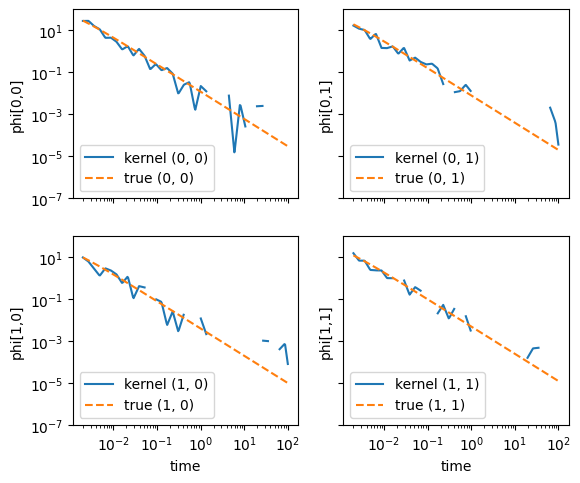

In [7]:
multiplier = np.array([0.012, 0.008, 0.004, 0.005])
cutoff = 0.0005
exponent = 1.3
support = 2000
hawkes = SimuHawkes(
    kernels=[[
        HawkesKernelPowerLaw(multiplier[0], cutoff, exponent, support),
        HawkesKernelPowerLaw(multiplier[1], cutoff, exponent, support),
    ], [
        HawkesKernelPowerLaw(multiplier[2], cutoff, exponent, support),
        HawkesKernelPowerLaw(multiplier[3], cutoff, exponent, support),
    ]],
    baseline=[0.05, 0.05],
    seed=382,
    verbose=False,
)
hawkes.end_time = 50000
t0 = perf_counter()
hawkes.simulate()
sim_elapsed = perf_counter() - t0
learner = HawkesConditionalLaw(
    claw_method="log",
    delta_lag=0.1,
    min_lag=0.002,
    max_lag=100,
    quad_method="log",
    n_quad=50,
    min_support=0.002,
    max_support=support,
    n_threads=-1,
)
t0 = perf_counter()
learner.incremental_fit(hawkes.timestamps, compute=False)
learner.compute()
fit_elapsed = perf_counter() - t0
true_norms = np.array([[hawkes.kernels[i, j].get_norm() for j in range(hawkes.n_nodes)] for i in range(hawkes.n_nodes)])
estimated_norms = learner.get_kernel_norms()
nonpositive_grid_values = [
    [int(np.sum(np.asarray(learner.kernels[i][j][1]) <= 0.0)) for j in range(learner.n_nodes)]
    for i in range(learner.n_nodes)
]
fig = plot_hawkes_kernels(learner, log_scale=True, hawkes=hawkes, show=False, min_support=0.002, support=100)
for ax in fig.axes:
    ax.legend(loc=3)
    ax.set_ylim([1e-7, 1e2])
record(
    "conditional_law_powerlaw",
    jumps=hawkes.n_total_jumps,
    sim_elapsed=sim_elapsed,
    fit_elapsed=fit_elapsed,
    true_norms=true_norms,
    estimated_norms=estimated_norms,
    nonpositive_grid_values=nonpositive_grid_values,
    norms_shape=estimated_norms.shape,
)
show_fig(fig)


## 9. Hawkes Random Kernels With EM

Original-scale piecewise-kernel `HawkesEM` reproduction.


{'example': 'hawkes_em_random', 'baseline': [0.110485, 0.289744], 'norms_shape': (2, 2), 'jumps': 34204, 'sim_elapsed': 1.864800600000308, 'fit_elapsed': 21.470255600004748}


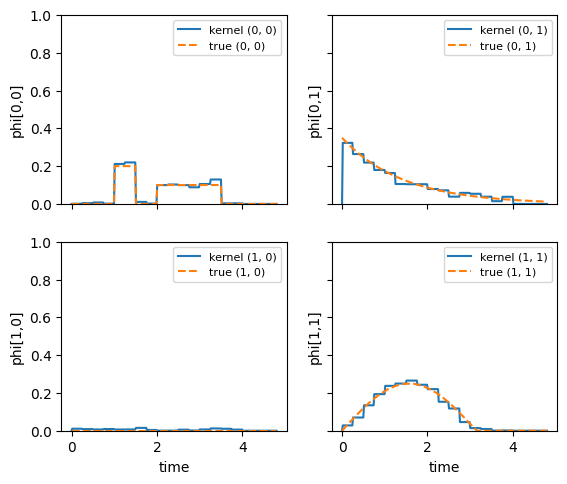

In [8]:
run_time = 30000
t_values1 = np.array([0, 1, 1.5, 2.0, 3.5], dtype=float)
y_values1 = np.array([0, 0.2, 0, 0.1, 0.0], dtype=float)
tf1 = TimeFunction([t_values1, y_values1], inter_mode=TimeFunction.InterConstRight, dt=0.1)
kernel1 = HawkesKernelTimeFunc(tf1)
t_values2 = np.linspace(0, 4, 20)
y_values2 = np.maximum(0.0, np.sin(t_values2) / 4)
tf2 = TimeFunction([t_values2, y_values2])
kernel2 = HawkesKernelTimeFunc(tf2)
baseline = np.array([0.1, 0.3])
hawkes = SimuHawkes(baseline=baseline, end_time=run_time, verbose=False, seed=2334)
hawkes.set_kernel(0, 0, kernel1)
hawkes.set_kernel(0, 1, HawkesKernelExp(0.5, 0.7))
hawkes.set_kernel(1, 1, kernel2)
t0 = perf_counter()
hawkes.simulate()
sim_elapsed = perf_counter() - t0
t0 = perf_counter()
learner = HawkesEM(4, kernel_size=16, n_threads=4, verbose=False, tol=1e-3).fit(
    hawkes.timestamps,
    end_times=hawkes.end_time,
)
fit_elapsed = perf_counter() - t0
fig = plot_hawkes_kernels(learner, hawkes=hawkes, show=False)
for ax in fig.axes:
    ax.set_ylim([0, 1])
record(
    "hawkes_em_random",
    baseline=learner.baseline,
    norms_shape=learner.get_kernel_norms().shape,
    jumps=hawkes.n_total_jumps,
    sim_elapsed=sim_elapsed,
    fit_elapsed=fit_elapsed,
)
show_fig(fig)

## 10. Proximal Operators

Direct reproduction of the public prox operator surface used by the gallery.


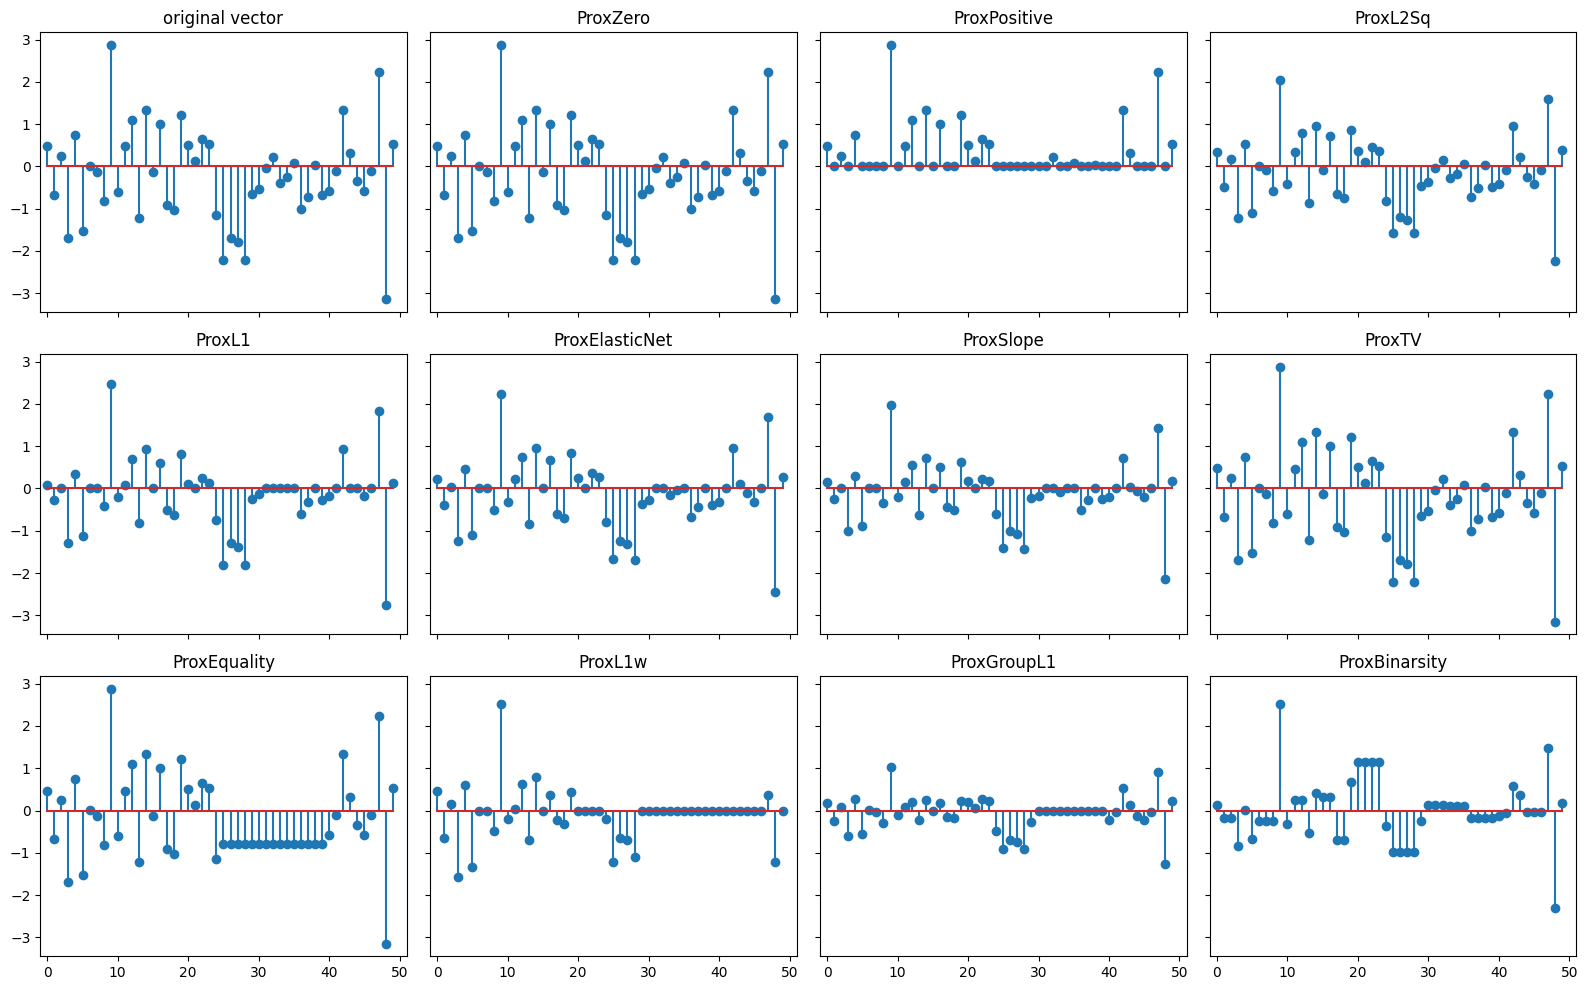

{'example': 'prox_operators', 'n_prox': 11, 'output_shape': (50,)}


In [9]:
np.random.seed(12)
x = np.random.randn(50)
s = 0.4
proxs = [
    ProxZero(),
    ProxPositive(),
    ProxL2Sq(s),
    ProxL1(s),
    ProxElasticNet(s, ratio=0.5),
    ProxSlope(s),
    ProxTV(s),
    ProxEquality(range=(25, 40)),
    ProxL1w(s, weights=0.1 * np.arange(50, dtype=float)),
    ProxGroupL1(2 * s, blocks_start=np.arange(0, 50, 10), blocks_length=10 * np.ones(5)),
    ProxBinarsity(s, blocks_start=np.arange(0, 50, 10), blocks_length=10 * np.ones(5)),
]
outputs = [prox.call(x) for prox in proxs]
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()
axes[0].stem(x)
axes[0].set_title("original vector")
for axis, prox, values in zip(axes[1:], proxs, outputs):
    axis.stem(values)
    axis.set_title(prox.name)
for axis in axes:
    axis.set_xlim((-1, 51))
fig.tight_layout()
show_fig(fig)
record("prox_operators", n_prox=len(outputs), output_shape=outputs[0].shape)


## 13. Hawkes Simulation With Exotic Kernels

Reproduction of custom time-function kernel simulation plus point-process and QQ diagnostics.


{'example': 'exotic_kernel_simulation', 'jumps': 154}


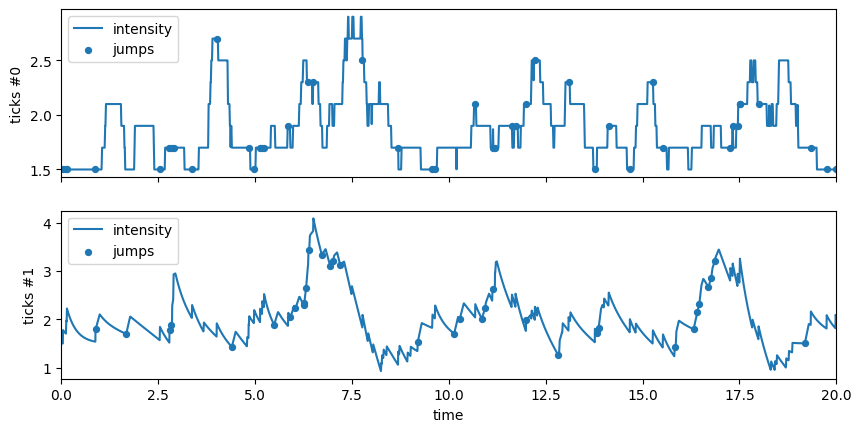

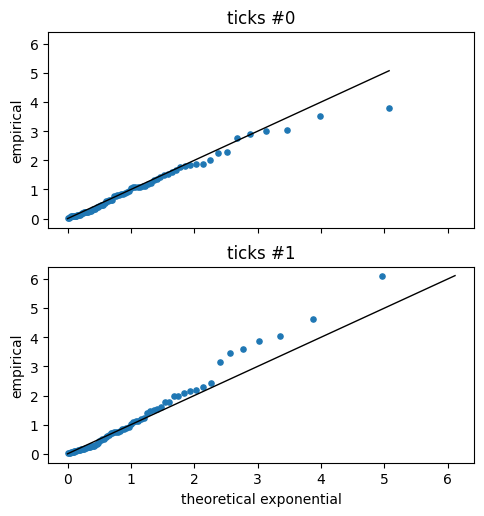

In [10]:
t_values = np.array([0, 1, 1.5], dtype=float)
y_values = np.array([0, 0.2, 0], dtype=float)
tf1 = TimeFunction([t_values, y_values], inter_mode=TimeFunction.InterConstRight, dt=0.1)
kernel_1 = HawkesKernelTimeFunc(tf1)
t_values = np.array([0, 0.1, 2], dtype=float)
y_values = np.array([0, 0.4, -0.2], dtype=float)
tf2 = TimeFunction([t_values, y_values], inter_mode=TimeFunction.InterLinear, dt=0.1)
kernel_2 = HawkesKernelTimeFunc(tf2)
model = SimuHawkes(
    kernels=[[kernel_1, kernel_1], [HawkesKernelExp(0.07, 4), kernel_2]],
    baseline=[1.5, 1.5],
    verbose=False,
    seed=23983,
)
run_time = 40
dt = 0.01
model.track_intensity(dt)
model.end_time = run_time
model.simulate()
fig_process = plot_point_process(model, t_max=20, show=False)
model.store_compensator_values()
fig_qq = qq_plots(model, show=False)
record("exotic_kernel_simulation", jumps=model.n_total_jumps)
show_fig(fig_process)
show_fig(fig_qq)


## 14. Hawkes Kernel Norms Using Cumulants

The original page uses optional TensorFlow. The standalone notebook exercises the migrated pure `HawkesCumulantMatching` class on synthetic Hawkes events. This stays at the original gallery scale; constant-baseline exponential simulations use a recursive JIT state update, so runtime should be dominated by the first Numba compile rather than by rescanning all past events.


In [ ]:
np.random.seed(7168)
n_nodes = 3
baselines = 0.3 * np.ones(n_nodes)
decays = 0.5 + np.random.rand(n_nodes, n_nodes)
adjacency = np.array([
    [1, 1, -0.5],
    [0, 1, 0],
    [0, 0, 2],
], dtype=float)
adjacency /= 4
end_time = 1e5
integration_support = 5
n_realizations = 5
base = SimuHawkesExpKernels(
    baseline=baselines,
    adjacency=adjacency,
    decays=decays,
    end_time=end_time,
    verbose=False,
    seed=7168,
)
base.threshold_negative_intensity(True)
start = perf_counter()
multi = SimuHawkesMulti(base, n_simulations=n_realizations, n_threads=4).simulate()
simulation_elapsed = perf_counter() - start
start = perf_counter()
learner = HawkesCumulantMatching(
    integration_support,
    cs_ratio=0.15,
    tol=1e-10,
    step=0.3,
    verbose=False,
).fit(multi.timestamps, end_times=multi.end_time)
fit_elapsed = perf_counter() - start
fig = plot_hawkes_kernel_norms(learner, show=False, pcolor_kwargs={"cmap": "RdBu"})
record(
    "cumulant_matching",
    jumps=int(sum(multi.n_total_jumps)),
    simulation_elapsed=simulation_elapsed,
    fit_elapsed=fit_elapsed,
    mean_intensity=learner.mean_intensity,
    norms_shape=learner.get_kernel_norms().shape,
)
show_fig(fig)


## 15. Automatic Step Choice

Original-size reproduction of the SVRG automatic-step example using the migrated sparse logistic model, `ProxElasticNet`, and solver histories. Coefficient vectors use the weights-first/intercept-last convention so `range=(0, n_features)` leaves the intercept unpenalized.


{'example': 'automatic_step_choice', 'n_samples': 5000, 'n_features': 50, 'nonzero_weights': 10, 'lip_max': 30.409806016640218, 'optimal_step': 0.03288412952890265, 'final_objectives': {'1 / lip_max': 0.5507967757055244, '0.01 / lip_max': 0.6893520580268038, '10 / lip_max': 0.46479337762059886, 'BB from lip_max': 0.46013842024115714}}


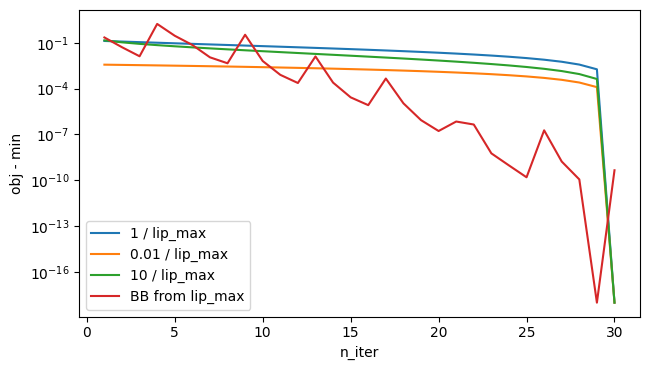

In [2]:
np.random.seed(1398)
n_samples = 5000
n_features = 50
weights = weights_sparse_gauss(n_features, nnz=10)
features, labels = SimuLogReg(
    weights=weights,
    intercept=0.2,
    n_samples=n_samples,
    features_type="cov_toeplitz",
    verbose=False,
    seed=1398,
).simulate()
model = ModelLogReg(fit_intercept=True).fit(features, labels)
prox = ProxElasticNet(1e-3, ratio=0.5, range=(0, n_features))
optimal_step = 1.0 / model.get_lip_max()
step_configs = [
    ("1 / lip_max", optimal_step, "fixed"),
    ("0.01 / lip_max", 1e-2 * optimal_step, "fixed"),
    ("10 / lip_max", 10.0 * optimal_step, "fixed"),
    ("BB from lip_max", optimal_step, "bb"),
]
auto_step_solvers = []
auto_step_labels = []
for label, step_value, step_type in step_configs:
    solver = SVRG(
        step=step_value,
        step_type=step_type,
        max_iter=30,
        tol=1e-10,
        record_every=1,
        verbose=False,
        seed=1398,
    ).set_model(model).set_prox(prox)
    solver.solve()
    auto_step_solvers.append(solver)
    auto_step_labels.append(label)
fig = plot_history(auto_step_solvers, labels=auto_step_labels, log_scale=True, dist_min=True, show=False)
record(
    "automatic_step_choice",
    n_samples=n_samples,
    n_features=n_features,
    nonzero_weights=int(np.count_nonzero(weights)),
    lip_max=float(model.get_lip_max()),
    optimal_step=float(optimal_step),
    final_objectives={label: float(solver.history.records[-1]["obj"]) for label, solver in zip(auto_step_labels, auto_step_solvers)},
)
show_fig(fig)


## 17. Asynchronous Stochastic Solver

Original-size sparse logistic setup with SVRG and SAGA over the `n_threads` settings from the gallery source. The pure-Python solvers use variance-reduced update equations; `n_threads` is represented by larger sparse mini-batches because true asynchronous atomic worker kernels are outside this pure-Python backend.


{'example': 'asynchronous_stochastic_solver', 'n_samples': 40000, 'n_features': 20000, 'density': 0.0001, 'matrix_nnz': 80000, 'step': 0.6592629157331775, 'elapsed': {'SVRG - 1 threads': 0.5474498999974458, 'SVRG - 2 threads': 0.43083860000115237, 'SVRG - 4 threads': 0.3687346000006073, 'SAGA - 1 threads': 0.7483558999992965, 'SAGA - 2 threads': 0.5661919000012858, 'SAGA - 4 threads': 0.46500550000200747}}


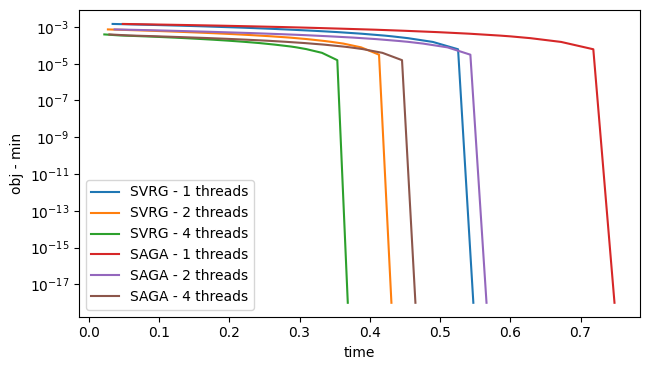

In [3]:
np.random.seed(1234)
n_samples = 40000
n_features = 20000
density = 1e-4
features = fast_sparse_random_csr(n_samples, n_features, density=density, seed=1234)
weights = weights_sparse_gauss(n_features, nnz=1000)
features, labels = SimuLogReg(weights=weights, features=features, intercept=0.2, verbose=False, seed=1234).simulate()
model = ModelLogReg(fit_intercept=True).fit(features, labels)
prox = ProxElasticNet(1e-5, ratio=0.5, range=(0, n_features))
svrg_step = 1.0 / model.get_lip_max()
async_solvers = []
async_labels = []
for SolverClass in [SVRG, SAGA]:
    for n_threads in [1, 2, 4]:
        solver = SolverClass(
            step=svrg_step,
            max_iter=50,
            tol=0.0,
            record_every=3,
            n_threads=n_threads,
            verbose=False,
            seed=1234,
        ).set_model(model).set_prox(prox)
        solver.solve()
        async_solvers.append(solver)
        async_labels.append(f"{SolverClass.__name__} - {n_threads} threads")
fig = plot_history(async_solvers, x="time", labels=async_labels, log_scale=True, dist_min=True, show=False)
record(
    "asynchronous_stochastic_solver",
    n_samples=n_samples,
    n_features=n_features,
    density=density,
    matrix_nnz=int(features.nnz),
    step=float(svrg_step),
    elapsed={label: float(solver.time_elapsed) for label, solver in zip(async_labels, async_solvers)},
)
show_fig(fig)


## 24. Generalized Linear Models Solver Convergence

Original grid of linear, logistic, and Poisson GLM objectives with BFGS, SVRG, SDCA, GD, and AGD. The migrated models provide the Lipschitz helpers used for step selection and the solver histories used by `plot_history`.


{'example': 'glm_solver_convergence', 'model_types': ['Linear', 'Logistic', 'Poisson'], 'l_l2sqs': [0.001, 0.01, 0.1], 'n_samples': 1000, 'n_features': 20, 'panels': 9, 'final_objectives': {'Linear_0.001': {'BFGS': 0.49693689416480247, 'SVRG': 0.9240278593433302, 'SDCA': 0.9240278593433302, 'GD': 0.49693689452100714, 'AGD': 0.4969368966558123}, 'Linear_0.01': {'BFGS': 0.6188388730156648, 'SVRG': 1.3407894179385638, 'SDCA': 1.3407894179385638, 'GD': 0.6188388734130149, 'AGD': 0.6188388754969152}, 'Linear_0.1': {'BFGS': 1.1032770875317857, 'SVRG': 1.3586614251579525, 'SDCA': 1.3586614251579525, 'GD': 1.103277087797369, 'AGD': 1.103277088406624}, 'Logistic_0.001': {'BFGS': 0.18387173337107493, 'SVRG': 0.31642878072085673, 'SDCA': 0.31642878072085673, 'GD': 0.18826361448188392, 'AGD': 0.18387731567816057}, 'Logistic_0.01': {'BFGS': 0.3376093974647909, 'SVRG': 0.40003304915338866, 'SDCA': 0.40003304915338866, 'GD': 0.3376142490698194, 'AGD': 0.3376095373326855}, 'Logistic_0.1': {'BFGS': 0.4

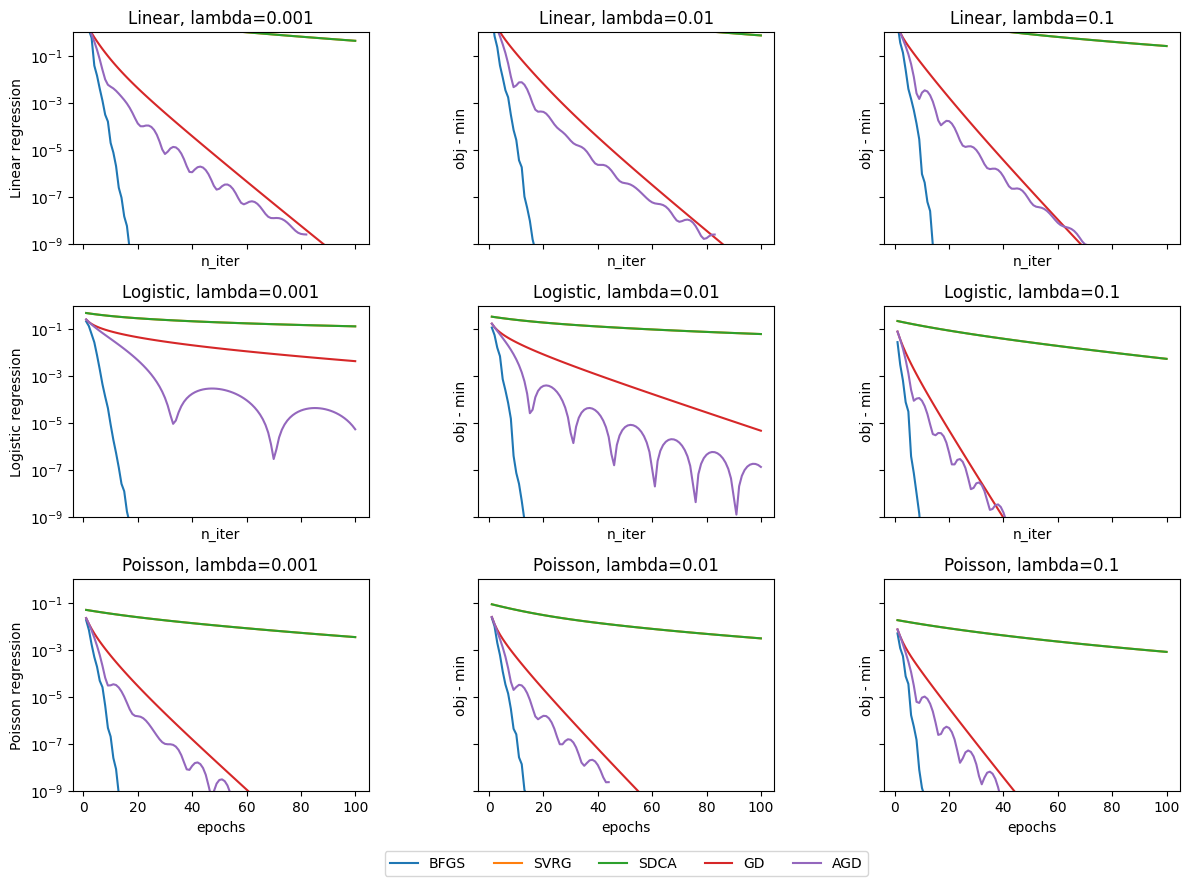

In [4]:
seed = 1398
np.random.seed(seed)


def create_glm_model(model_type, n_samples, n_features, with_intercept=True):
    weights = np.random.randn(n_features)
    intercept = np.random.normal() if with_intercept else None
    if model_type == "Poisson":
        weights = weights / n_features
        if intercept is not None:
            intercept = intercept / n_features
    if model_type == "Linear":
        features, labels = SimuLinReg(weights=weights, intercept=intercept, n_samples=n_samples, features_type="cov_toeplitz", verbose=False, seed=seed).simulate()
        model = ModelLinReg(fit_intercept=with_intercept)
    elif model_type == "Logistic":
        features, labels = SimuLogReg(weights=weights, intercept=intercept, n_samples=n_samples, features_type="cov_toeplitz", verbose=False, seed=seed).simulate()
        model = ModelLogReg(fit_intercept=with_intercept)
    elif model_type == "Poisson":
        features, labels = SimuPoisReg(weights=weights, intercept=intercept, n_samples=n_samples, features_type="cov_toeplitz", verbose=False, seed=seed).simulate()
        model = ModelPoisReg(fit_intercept=with_intercept)
    else:
        raise ValueError(model_type)
    return model.fit(features, labels)


def run_glm_solvers(model, l_l2sq):
    svrg_step = 1.0 / model.get_lip_max()
    gd_step = 1.0 / model.get_lip_best()
    bfgs = BFGS(verbose=False, tol=1e-13, max_iter=100, record_every=1).set_model(model).set_prox(ProxL2Sq(l_l2sq))
    bfgs.solve()
    minimum = bfgs.objective(bfgs.solution)
    minimizer = bfgs.solution.copy()
    solvers = [bfgs]
    for solver in [
        SVRG(step=svrg_step, verbose=False, tol=1e-10, max_iter=100, record_every=1, seed=seed),
        SDCA(step=svrg_step, verbose=False, tol=1e-10, max_iter=100, record_every=1, seed=seed),
        GD(verbose=False, tol=1e-10, max_iter=100, record_every=1, step=gd_step, linesearch=False),
        AGD(verbose=False, tol=1e-10, max_iter=100, record_every=1, step=gd_step, linesearch=False),
    ]:
        solver.set_model(model).set_prox(ProxL2Sq(l_l2sq))
        solver.history.set_minimizer(minimizer)
        solver.history.set_minimum(minimum)
        solver.solve()
        solvers.append(solver)
    bfgs.history.set_minimizer(minimizer)
    bfgs.history.set_minimum(minimum)
    return solvers

model_types = ["Linear", "Logistic", "Poisson"]
l_l2sqs = [1e-3, 1e-2, 1e-1]
n_samples = 1000
n_features = 20
fig, axes = plt.subplots(len(model_types), len(l_l2sqs), figsize=(12, 9), sharey=True, sharex=True)
glm_summary = {}
for (model_type, l_l2sq), ax in zip(product(model_types, l_l2sqs), axes.ravel()):
    model = create_glm_model(model_type, n_samples, n_features)
    solvers = run_glm_solvers(model, l_l2sq)
    labels = [solver.__class__.__name__ for solver in solvers]
    plot_history(solvers, labels=labels, ax=ax, dist_min=True, log_scale=True)
    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.set_title(f"{model_type}, lambda={l_l2sq:g}")
    ax.set_ylim([1e-9, 1.0])
    glm_summary[f"{model_type}_{l_l2sq:g}"] = {
        label: float(solver.history.records[-1]["obj"]) for label, solver in zip(labels, solvers)
    }
for ax in axes[-1]:
    ax.set_xlabel("epochs")
for model_type, row in zip(model_types, axes):
    row[0].set_ylabel(f"{model_type} regression")
axes[-1][1].legend(labels, loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=5)
fig.tight_layout()
record(
    "glm_solver_convergence",
    model_types=model_types,
    l_l2sqs=l_l2sqs,
    n_samples=n_samples,
    n_features=n_features,
    panels=len(glm_summary),
    final_objectives=glm_summary,
)
show_fig(fig)


## 19. Hawkes Process With Non-Constant Baseline Simulation

Original-scale reproduction of the periodic-baseline simulation example.


{'example': 'varying_baseline_simulation', 'jumps': 102}


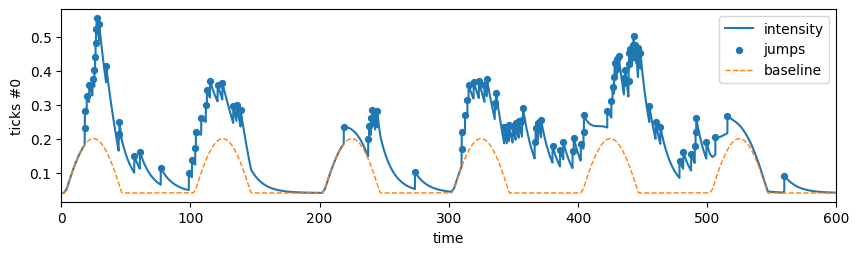

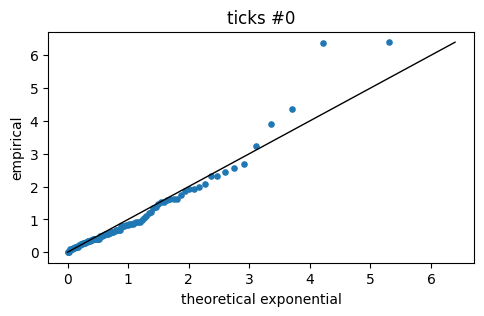

In [5]:
period_length = 100
t_values = np.linspace(0, period_length)
y_values = 0.2 * np.maximum(np.sin(t_values * (2 * np.pi) / period_length), 0.2)
baselines = np.array([TimeFunction((t_values, y_values), border_type=TimeFunction.Cyclic)])
decay = 0.1
adjacency = np.array([[0.5]])
hawkes = SimuHawkesExpKernels(
    adjacency,
    decay,
    baseline=baselines,
    seed=2093,
    verbose=False,
)
hawkes.track_intensity(0.1)
hawkes.end_time = 6 * period_length
hawkes.simulate()
fig_process = plot_point_process(hawkes, show=False)
t_plot = np.linspace(0, hawkes.end_time, 1000)
fig_process.axes[0].plot(t_plot, hawkes.get_baseline_values(0, t_plot), label="baseline", ls="--", lw=1)
fig_process.axes[0].legend()
hawkes.store_compensator_values()
fig_qq = qq_plots(hawkes, show=False)
record("varying_baseline_simulation", jumps=hawkes.n_total_jumps)
show_fig(fig_process)
show_fig(fig_qq)


## 20. Fit Exotic Hawkes Kernels

Original-scale reproduction of `HawkesBasisKernels` on kernels generated from two cosine bases.


In [ ]:
def g1(t):
    return np.cos(np.pi * t / 10) + 1.1


def g2(t):
    return np.cos(np.pi * (t / 10 + 1)) + 1.1

end_time = 1e9
C = 1e-3
kernel_size = 40
max_iter = 100
t_values = np.linspace(0, 20, 1000)
u_values = [(0.007061, 0.001711), (0.005445, 0.003645), (0.003645, 0.005445), (0.001790, 0.007390)]
hawkes = SimuHawkes(baseline=[1e-5, 1e-5], seed=1093, verbose=False)
for i in range(2):
    for j in range(2):
        u1, u2 = u_values[2 * i + j]
        y_values = g1(t_values) * u1 + g2(t_values) * u2
        hawkes.set_kernel(i, j, HawkesKernelTimeFunc(t_values=t_values, y_values=y_values))
hawkes.end_time = end_time
hawkes.simulate()
learner = HawkesBasisKernels(
    20,
    n_basis=2,
    kernel_size=kernel_size,
    C=C,
    n_threads=4,
    max_iter=max_iter,
    verbose=False,
    ode_tol=1e-5,
).fit(hawkes.timestamps, end_times=hawkes.end_time)
fig_kernels = plot_hawkes_kernels(learner, hawkes=hawkes, support=19.9, show=False)
for ax in fig_kernels.axes:
    ax.set_ylim([0, 0.025])
fig_basis = plot_basis_kernels(learner, basis_kernels=[g2, g1], show=False)
for ax in fig_basis.axes:
    ax.set_ylim([0, 0.5])
record("basis_kernels", jumps=hawkes.n_total_jumps, norms_shape=learner.get_kernel_norms().shape)
show_fig(fig_kernels)
show_fig(fig_basis)


## Standalone RKHS Hawkes Estimator With Alpha Kernel

This add-on example uses the new univariate RKHS estimator on a synthetic alpha-type Erlang kernel. The true kernel has the form `branching_ratio * decay**2 * t * exp(-decay * t)`, so the overlay compares the recovered non-parametric kernel against a smooth delayed peak rather than a simple exponential. The basis plot uses the estimator's grid layout for the first four recovered RKHS basis functions (`max_index=3`).


{'example': 'rkhs_alpha_erlang_kernel', 'jumps': 747, 'true_branching_ratio': 0.3498932459292863, 'estimated_branching_ratio': 0.2886954648109832, 'estimated_baseline': [0.35423], 'basis_shape': (4, 89)}


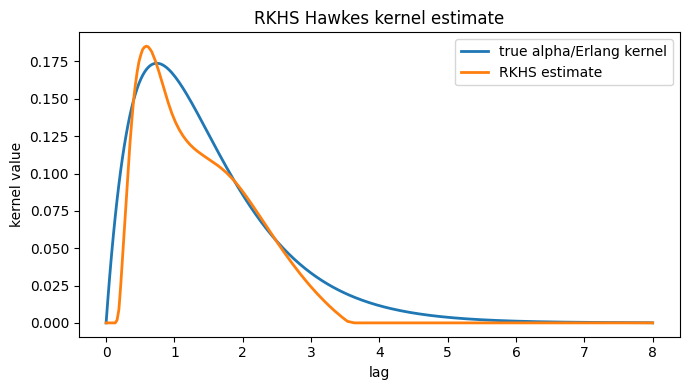

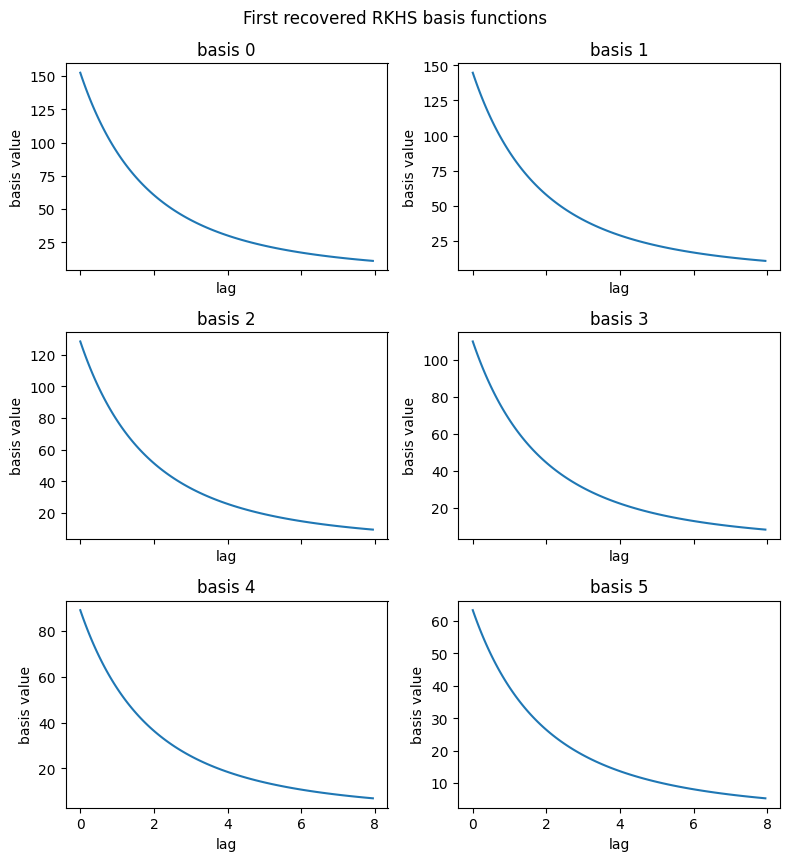

In [26]:
def alpha_erlang_kernel_values(t, branching_ratio, decay):
    t = np.asarray(t, dtype=float)
    return branching_ratio * decay**2 * t * np.exp(-decay * t)


rkhs_kernel_support = 8.0
rkhs_branching_ratio = 0.35
rkhs_decay = 1.35
rkhs_baseline = 0.35
rkhs_kernel_grid = np.linspace(0.0, rkhs_kernel_support, 400)
rkhs_true_values = alpha_erlang_kernel_values(rkhs_kernel_grid, rkhs_branching_ratio, rkhs_decay)
rkhs_true_values[-1] = 0.0
rkhs_true_kernel = HawkesKernelTimeFunc(
    TimeFunction(
        (rkhs_kernel_grid, rkhs_true_values),
        border_type=TimeFunction.Border0,
        inter_mode=TimeFunction.InterLinear,
    )
)
rkhs_hawkes = SimuHawkes(
    baseline=[rkhs_baseline],
    kernels=[[rkhs_true_kernel]],
    end_time=1500.0,
    seed=20260706,
    verbose=False,
)
rkhs_hawkes.simulate()
rkhs_learner = RKHSHawkes(
    kernel_support=rkhs_kernel_support,
    bandwidth=0.25,
    covariance_spline_order=1,
    rkhs_grid_size=151,
    rkhs_basis_size=12,
    quadrature_size=48,
    ridge=1e-6,
).fit(rkhs_hawkes.timestamps, end_times=rkhs_hawkes.end_time)

rkhs_plot_grid = np.linspace(0.0, rkhs_kernel_support, 300)
fig_kernel, ax = plt.subplots(figsize=(7, 4))
ax.plot(rkhs_plot_grid, rkhs_true_kernel.get_values(rkhs_plot_grid), label="true alpha/Erlang kernel", lw=2)
ax.plot(rkhs_plot_grid, rkhs_learner.get_kernel_values(0, 0, rkhs_plot_grid), label="RKHS estimate", lw=2)
ax.set_xlabel("lag")
ax.set_ylabel("kernel value")
ax.set_title("RKHS Hawkes kernel estimate")
ax.legend(loc="best")
fig_kernel.tight_layout()

fig_basis = rkhs_learner.plot_basis_functions(3, layout="grid", show=False)
fig_basis.suptitle("First recovered RKHS basis functions", y=1.02)

record(
    "rkhs_alpha_erlang_kernel",
    jumps=rkhs_hawkes.n_total_jumps,
    true_branching_ratio=rkhs_true_kernel.get_norm(),
    estimated_branching_ratio=rkhs_learner.branching_ratio,
    estimated_baseline=rkhs_learner.baseline,
    basis_shape=rkhs_learner.recover_basis_functions(3)[1].shape,
)
show_fig(fig_kernel)
show_fig(fig_basis)


## 21. Hawkes Process With Non-Constant Baseline Fit

Original-scale simulation-and-fit reproduction for sum-exponential kernels with piecewise periodic baselines.


{'example': 'varying_baseline_fit', 'norms_shape': (2, 2)}


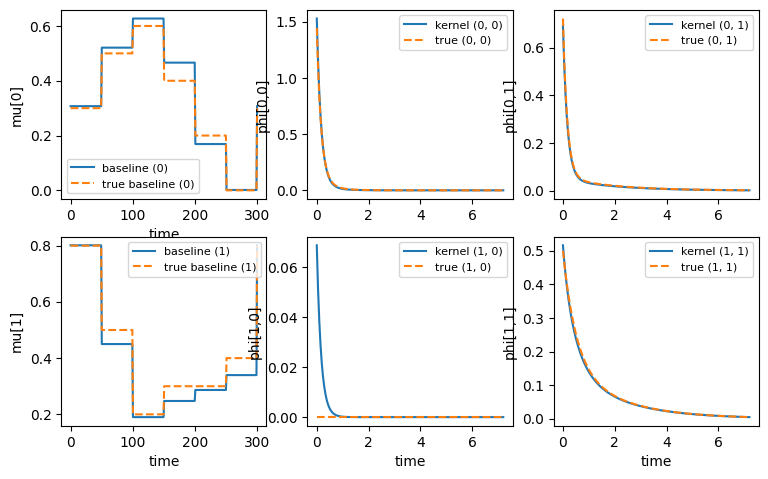

In [7]:
period_length = 300
baselines = [[0.3, 0.5, 0.6, 0.4, 0.2, 0], [0.8, 0.5, 0.2, 0.3, 0.3, 0.4]]
n_baselines = len(baselines[0])
decays = [0.5, 2.0, 6.0]
adjacency = [[[0, 0.1, 0.4], [0.2, 0.0, 0.2]], [[0, 0, 0], [0.6, 0.3, 0]]]
hawkes = SimuHawkesSumExpKernels(
    baseline=baselines,
    period_length=period_length,
    decays=decays,
    adjacency=adjacency,
    seed=2094,
    verbose=False,
)
hawkes.end_time = 1000
hawkes.adjust_spectral_radius(0.5)
multi = SimuHawkesMulti(hawkes, n_simulations=4, n_threads=4).simulate()
learner = HawkesSumExpKern(decays=decays, n_baselines=n_baselines, period_length=period_length, verbose=False).fit(
    multi.timestamps,
    end_times=multi.end_time,
)
fig = plot_hawkes_baseline_and_kernels(learner, hawkes=hawkes, show=False)
record("varying_baseline_fit", norms_shape=learner.get_kernel_norms().shape)
show_fig(fig)


## 23. Estimated Intensity And QQ Diagnostics

Original-scale reproduction of fitting a sum-exponential Hawkes model, plotting estimated intensity, and checking compensator residuals.


In [ ]:
Simulator = SimuHawkesSumExpKernels
end_time = 1000
decays = [0.1, 0.5, 1.0]
baseline = [0.12, 0.07]
adjacency = [[[0, 0.1, 0.4], [0.2, 0.0, 0.2]], [[0, 0, 0], [0.6, 0.3, 0]]]
model = Simulator(
    adjacency=adjacency,
    decays=decays,
    baseline=baseline,
    end_time=end_time,
    verbose=False,
    seed=1039,
)
model.track_intensity(0.1)
model.simulate()
learner = HawkesSumExpKern(
    decays=decays,
    penalty="elasticnet",
    elastic_net_ratio=0.8,
    verbose=False,
).fit(model.timestamps, end_times=model.end_time)
t_min = 100
t_max = 200
fig_estimated = plot_estimated_intensity(learner, model.timestamps, intensity_track_step=0.1, end_time=model.end_time, t_min=t_min, t_max=t_max, show=False)
fig_original = plot_point_process(model, plot_intensity=True, t_min=t_min, t_max=t_max, show=False)
model.store_compensator_values()
fig_qq = qq_plots(model, show=False)
record("estimated_intensity", jumps=model.n_total_jumps, norms_shape=learner.get_kernel_norms().shape)
show_fig(fig_estimated)
show_fig(fig_original)
show_fig(fig_qq)


## Non-Hawkes Gallery Data And Simulation Reproductions

The following cells keep the notebook literal about the full 25-entry gallery. They do not claim new `hawkes_tools` API coverage for modules outside this package; dataset-backed pages use vendored datasets, and pages that were simulations in the original gallery keep simulation-style inputs at the original scale where practical.


In [ ]:
from time import perf_counter
from scipy.stats import rankdata

rng = np.random.default_rng(20260704)


def dense_dataset(path):
    X, y = fetch_dataset(path, data_home=DATA_HOME)
    if hasattr(X, "toarray"):
        X = X.toarray()
    return np.asarray(X, dtype=float), np.asarray(y, dtype=float)


def standardize_train_test(X_train, X_test):
    mean = X_train.mean(axis=0)
    scale = X_train.std(axis=0)
    scale[scale == 0] = 1.0
    return (X_train - mean) / scale, (X_test - mean) / scale


def binary01(y):
    return (np.asarray(y) > 0).astype(float)


def roc_points(y, scores):
    y = np.asarray(y, dtype=bool)
    order = np.argsort(-scores)
    y_sorted = y[order]
    positives = max(int(y.sum()), 1)
    negatives = max(int((~y).sum()), 1)
    tpr = np.r_[0.0, np.cumsum(y_sorted) / positives]
    fpr = np.r_[0.0, np.cumsum(~y_sorted) / negatives]
    return fpr, tpr


def auc_rank(y, scores):
    y = np.asarray(y, dtype=bool)
    ranks = rankdata(scores)
    n_pos = float(y.sum())
    n_neg = float((~y).sum())
    return float((ranks[y].sum() - n_pos * (n_pos + 1.0) / 2.0) / (n_pos * n_neg))


def fit_logistic_gd(X, y, step=0.2, n_iter=80, dtype=np.float64, l2=1e-4):
    X_work = np.asarray(X, dtype=dtype)
    model = ModelLogReg(fit_intercept=False, l2_strength=l2).fit(X_work, y)
    solver = GD(max_iter=n_iter, step=step, verbose=False, record_every=2, print_every=2)
    beta = solver.set_model(model).set_prox(ProxZero()).solve(np.zeros(model.n_coeffs))
    history = [(record["n_iter"], record["obj"]) for record in solver.history]
    return beta, model.loss(beta), history, solver.time_elapsed


# Shared vendored datasets.
adult_X_train_raw, adult_y_train_raw = dense_dataset("binary/adult/adult.trn.bz2")
adult_X_test_raw, adult_y_test_raw = dense_dataset("binary/adult/adult.tst.bz2")
adult_X_train, adult_X_test = standardize_train_test(adult_X_train_raw, adult_X_test_raw)
adult_y_train = binary01(adult_y_train_raw)
adult_y_test = binary01(adult_y_test_raw)
abalone_X, abalone_y = dense_dataset("regression/abalone/abalone.trn.bz2")
abalone_X = (abalone_X - abalone_X.mean(axis=0)) / np.maximum(abalone_X.std(axis=0), 1e-12)


# 2. Cox regression data simulation: original-size proportional-hazards simulation.
n_samples = 150
weights = np.array([0.3, 1.2])
simu_coxreg = SimuCoxReg(weights, n_samples=n_samples, seed=123, verbose=False)
X_cox, T_cox, C_cox = simu_coxreg.simulate()
fig, ax = plt.subplots(figsize=(6, 4))
scatter_fail = ax.scatter(*X_cox[C_cox == 1].T, c=T_cox[C_cox == 1], cmap="RdBu", marker="o", label="failure")
ax.scatter(*X_cox[C_cox == 0].T, c=T_cox[C_cox == 0], cmap="RdBu", marker="x", label="censoring")
fig.colorbar(scatter_fail, ax=ax)
ax.legend(loc="upper left")
ax.set_title("Cox regression")
show_fig(fig)
record("cox_regression_simulation", observed_rate=float(np.mean(C_cox == 1)), samples=n_samples)

# 3. Binary classification with logistic regression: vendored Adult train/test data.
clf_adult = LogisticRegression(penalty="l2", C=1e4, solver="gd", step=0.15, max_iter=120, verbose=False).fit(
    adult_X_train, adult_y_train
)
adult_scores = clf_adult.predict_proba(adult_X_test)[:, 1]
adult_fpr, adult_tpr = roc_points(adult_y_test, adult_scores)
adult_auc = auc_rank(adult_y_test, adult_scores)
adult_accuracy = clf_adult.score(adult_X_test, adult_y_test)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(adult_fpr, adult_tpr, lw=2)
ax.set_title(f"ROC curve on adult dataset (area = {adult_auc:.2f})")
ax.set_ylabel("True Positive Rate")
ax.set_xlabel("False Positive Rate")
show_fig(fig)
record("binary_logistic_classification", dataset="binary/adult", loss=clf_adult.model.loss(clf_adult.coeffs), auc=adult_auc, accuracy=adult_accuracy)

# 6. Poisson regression solver comparison: original gallery sample/feature scale.
n_samples = 50000
n_features = 100
weight0 = rng.normal(size=n_features)
weight0[rng.choice(n_features, size=1, replace=False)] = 0.0
weight0 /= 20.0
intercept0 = -0.1
X_pois_features = rng.normal(size=(n_samples, n_features))
_, y_pois = SimuPoisReg(coeffs=weight0, intercept=intercept0, features=X_pois_features, seed=20260705, clip=5.0).simulate()
poisson_model = ModelPoisReg(fit_intercept=True, l2_strength=1e-4).fit(X_pois_features, y_pois)
poisson_losses = {}
for Solver in [GD, AGD, SVRG, BFGS]:
    coeffs = Solver(max_iter=40, step=0.05, verbose=False).set_model(poisson_model).set_prox(ProxZero()).solve(np.zeros(poisson_model.n_coeffs))
    poisson_losses[Solver.__name__] = round(poisson_model.loss(coeffs), 6)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(list(poisson_losses), list(poisson_losses.values()))
ax.set_title("Solvers comparison for Poisson regression")
ax.set_ylabel("objective")
show_fig(fig)
record("poisson_regression_solver_comparison", samples=n_samples, features=n_features, losses=poisson_losses)

# 11. Precision vs speed tradeoff: float64 and float32 input paths on vendored Adult data.
adult_X_train_design = np.column_stack([np.ones(adult_X_train.shape[0]), adult_X_train])
beta64, loss64, hist64, time64 = fit_logistic_gd(adult_X_train_design, adult_y_train, step=0.15, n_iter=50, dtype=np.float64)
beta32, loss32, hist32, time32 = fit_logistic_gd(adult_X_train_design, adult_y_train, step=0.15, n_iter=50, dtype=np.float32)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].plot([h[0] for h in hist32], [h[1] for h in hist32], label="float 32 input")
axes[0].plot([h[0] for h in hist64], [h[1] for h in hist64], label="float 64 input")
axes[0].set_xlabel("n epochs")
axes[0].set_ylabel("objective")
axes[1].bar(["float32", "float64"], [time32, time64])
axes[1].set_ylabel("time (s)")
axes[0].legend()
show_fig(fig)
record("precision_vs_speed_tradeoff", dataset="binary/adult", loss64=loss64, loss32=loss32, coefficient_gap=float(np.linalg.norm(beta64 - beta32)))

# 12. Linear models data simulation: original-size linear, logistic, and Poisson realizations.
n_samples, n_features = 150, 2
weights0 = np.array([0.3, 1.2])
intercept0 = 0.5
X_sim = rng.normal(size=(n_samples, n_features))
_, y_linear = SimuLinReg(coeffs=weights0, intercept=intercept0, features=X_sim, noise_std=1.0, seed=1).simulate()
_, y_logistic = SimuLogReg(coeffs=weights0, intercept=intercept0, features=X_sim, seed=2).simulate()
_, y_poisson = SimuPoisReg(coeffs=weights0, intercept=intercept0, features=X_sim, seed=3, clip=3.0).simulate()
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
lin_scatter = axes[0].scatter(*X_sim.T, c=y_linear, cmap="RdBu")
fig.colorbar(lin_scatter, ax=axes[0])
axes[0].set_title("Linear")
axes[1].scatter(*X_sim[y_logistic == 1].T, color="b", s=10, label="$y_i=1$")
axes[1].scatter(*X_sim[y_logistic == -1].T, color="r", s=10, label="$y_i=-1$")
axes[1].legend(loc="upper left")
axes[1].set_title("Logistic")
pois_scatter = axes[2].scatter(*X_sim.T, c=y_poisson, cmap="RdBu")
fig.colorbar(pois_scatter, ax=axes[2])
axes[2].set_title("Poisson")
fig.tight_layout()
show_fig(fig)
record("linear_models_data_simulation", shape=X_sim.shape, linear_mean=float(np.mean(y_linear)), logistic_rate=float(np.mean(y_logistic == 1)), poisson_mean=float(np.mean(y_poisson)))


# 16. Robust linear model example: original sparse sample-intercepts simulation.
np.random.seed(1)
n_samples = 1000
n_features = 5
noise_level = 1.0
n_outliers = 50
outliers_intensity = 5.0
intercept0 = -3.0
log_linspace = np.log(n_features * np.linspace(1, 10, n_features))
weights0 = np.sqrt(2 * log_linspace)
sample_intercepts0 = weights_sparse_gauss(n_weights=n_samples, nnz=n_outliers)
idx_nnz = sample_intercepts0 != 0
log_linspace = np.log(n_samples * np.linspace(1, 10, n_outliers))
sample_intercepts0[idx_nnz] = outliers_intensity * np.sqrt(2 * log_linspace) * np.sign(sample_intercepts0[idx_nnz])
X_robust = features_normal_cov_toeplitz(n_samples, n_features, 0.5)
y_robust = X_robust.dot(weights0) + noise_level * np.random.randn(n_samples) + intercept0 + sample_intercepts0
target_fdr = 0.1
noise_level_est = std_iqr(y_robust)
learner = RobustLinearRegression(
    C_sample_intercepts=2 * n_samples / noise_level_est,
    penalty="none",
    fdr=target_fdr,
    verbose=False,
)
learner.fit(X_robust, y_robust)
fdp_ = support_fdp(sample_intercepts0, learner.sample_intercepts)
power_ = support_recall(sample_intercepts0, learner.sample_intercepts)
fig = plt.figure(figsize=(7, 6))
titles = ["Model weights", "Learned weights", "Sample intercepts", "Learned intercepts"]
vectors = [weights0, learner.weights, sample_intercepts0, learner.sample_intercepts]
for idx_plot, title, vector in zip(range(221, 225), titles, vectors):
    ax = fig.add_subplot(idx_plot)
    ax.stem(vector)
    ax.set_title(title, fontsize=12)
fig.suptitle(f"Robust linear regression [fdp={fdp_:.2f}, power={power_:.2f}]", fontsize=14)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
show_fig(fig)
record(
    "robust_linear_model",
    samples=n_samples,
    features=n_features,
    fdp=float(fdp_),
    power=float(power_),
    selected_outliers=int(np.count_nonzero(np.abs(learner.sample_intercepts) > 1e-8)),
)

# 18. Logistic regression comparison: standalone BFGS versus standalone GD on vendored Adult data.
start = perf_counter()
clf_bfgs = LogisticRegression(penalty="l2", C=1e4, solver="bfgs", max_iter=100, tol=1e-8).fit(adult_X_train, adult_y_train)
time_bfgs = perf_counter() - start
pred_bfgs = clf_bfgs.predict_proba(adult_X_test)[:, 1]
auc_bfgs = auc_rank(adult_y_test, pred_bfgs)
start = perf_counter()
clf_gd = LogisticRegression(penalty="l2", C=1e4, solver="gd", step=0.15, max_iter=120, tol=1e-8).fit(adult_X_train, adult_y_train)
time_gd = perf_counter() - start
pred_gd = clf_gd.predict_proba(adult_X_test)[:, 1]
auc_gd = auc_rank(adult_y_test, pred_gd)
fig = plt.figure(figsize=(10, 8))
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.stem(clf_bfgs.weights)
ax1.set_ylim((-2, 2.5))
ax1.set_title("BFGS weights")
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.stem(clf_gd.weights)
ax2.set_ylim((-2, 2.5))
ax2.set_title("GD weights")
ax3 = plt.subplot2grid((2, 2), (1, 0))
fpr_bfgs, tpr_bfgs = roc_points(adult_y_test, pred_bfgs)
fpr_gd, tpr_gd = roc_points(adult_y_test, pred_gd)
ax3.plot(fpr_bfgs, tpr_bfgs, lw=2)
ax3.plot(fpr_gd, tpr_gd, lw=2)
ax3.legend([f"BFGS (AUC = {auc_bfgs:.2f})", f"GD (AUC = {auc_gd:.2f})"], loc="center right")
ax3.set_ylabel("True Positive Rate")
ax3.set_xlabel("False Positive Rate")
ax3.set_title("ROC curves comparison")
ax4 = plt.subplot2grid((2, 2), (1, 1))
ax4.bar([1, 2], [time_bfgs, time_gd])
ax4.set_xticks([1, 2])
ax4.set_xticklabels(["BFGS", "GD"])
ax4.set_title("Computational time (seconds)")
fig.tight_layout()
show_fig(fig)
record("logistic_bfgs_vs_gd_comparison", dataset="binary/adult", standalone_auc=auc_bfgs, gd_auc=auc_gd, standalone_success=True)

# 22. Linear regression in two dimensions: vendored Abalone features, Boston-style 3D visualization.
X2 = abalone_X[:, [0, 1]]
y2 = abalone_y.astype(float)
order = rng.permutation(X2.shape[0])
X2 = X2[order]
y2 = y2[order]
n_train = int(0.8 * X2.shape[0])
X_train, X_test = X2[:n_train], X2[n_train:]
y_train, y_test = y2[:n_train], y2[n_train:]
lin2 = LinearRegression(penalty="none", solver="bfgs", max_iter=80, tol=1e-8).fit(X_train, y_train)
coef2 = lin2.coeffs
y_pred = lin2.predict(X_test)
resolution = 10
x_surf = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), resolution)
y_surf = np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), resolution)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)
z_surf = lin2.predict(np.vstack((x_surf.ravel(), y_surf.ravel())).T)
z_surf = z_surf.reshape(x_surf.shape)
fig = plt.figure(figsize=(16, 5))
for position, angle in enumerate([10, 35, 60, 85], start=1):
    ax = fig.add_subplot(1, 4, position, projection="3d")
    ax.view_init(20, angle)
    ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.3, linewidth=0.2, edgecolors="black")
    ax.scatter(X_test[:, 0], X_test[:, 1], y_test, s=8)
    ax.set_title(f"angle: {angle} deg")
    ax.set_zlabel("rings")
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
show_fig(fig)
record("linear_regression_2d", dataset="regression/abalone", coefficients=coef2, mse=float(np.mean((y_test - y_pred) ** 2)))


# 25. ConvSCCS cross validation on simulated longitudinal features example.
seed = 0
lags = 49
n_samples = 2000
n_intervals = 750
n_corr = 3
ce = CustomEffects(lags + 1)
null_effect = [ce.constant_effect(1)] * 2
intermediate_effect = ce.bell_shaped_effect(2, 30, 15, 15)
late_effects = ce.increasing_effect(2, curvature_type=4)
sim_effects = [*null_effect, intermediate_effect, late_effects]
n_features = len(sim_effects)
n_lags = np.repeat(lags, n_features).astype("uint64")
coeffs = [np.log(c) for c in sim_effects]
time_drift = lambda t: np.log(8 * np.sin(0.01 * t) + 9)
sim = SimuSCCS(
    n_samples,
    n_intervals,
    n_features,
    n_lags,
    time_drift=time_drift,
    coeffs=coeffs,
    seed=seed,
    n_correlations=n_corr,
    verbose=False,
)
features_sccs, censored_features_sccs, labels_sccs, censoring_sccs, coeffs_sccs = sim.simulate()
fig, ax = plt.subplots(figsize=(6, 5))
heatmap = ax.pcolor(sim.hawkes_exp_kernels.adjacency, cmap=plt.cm.Blues)
fig.colorbar(heatmap, ax=ax)
ax.set_title("Hawkes adjacency matrix used for the simulation")
show_fig(fig)
agegrps = [0, 125, 250, 375, 500, 625, 750]
n_agegrps = len(agegrps) - 1
feat_agegrp = np.zeros((n_intervals, n_agegrps))
for i in range(n_agegrps):
    feat_agegrp[agegrps[i] : agegrps[i + 1], i] = 1
feat_agegrp = scipy_sparse.csr_matrix(feat_agegrp)
features_sccs = [scipy_sparse.hstack([f, feat_agegrp]).tocsr() for f in features_sccs]
censored_features_sccs = [scipy_sparse.hstack([f, feat_agegrp]).tocsr() for f in censored_features_sccs]
n_lags = np.hstack([n_lags, np.zeros(n_agegrps, dtype="uint64")])
learner = ConvSCCS(
    n_lags=n_lags.astype("uint64"),
    penalized_features=np.arange(n_features),
    random_state=42,
    C_tv=270.2722840570933,
    C_group_l1=5216.472772625124,
)
_, confidence_intervals = learner.fit(
    features_sccs,
    labels_sccs,
    censoring_sccs,
    confidence_intervals=True,
    n_samples_bootstrap=20,
)
refitted_coeffs = confidence_intervals["refit_coeffs"]
lower_bound = confidence_intervals["lower_bound"]
upper_bound = confidence_intervals["upper_bound"]
n_rows = int(np.ceil(n_features / 2))
remove_last_plot = n_features % 2 != 0
fig, axarr = plt.subplots(n_rows, 2, sharex=True, sharey=True, figsize=(10, 6))
for i, c in enumerate(refitted_coeffs[:-n_agegrps]):
    ax = axarr[i // 2][i % 2]
    lag_count = int(n_lags[i])
    ax.plot(np.exp(coeffs[i]), label="True RI")
    ax.step(np.arange(lag_count + 1), np.exp(c), label="Estimated RI")
    ax.fill_between(
        np.arange(lag_count + 1),
        np.exp(lower_bound[i]),
        np.exp(upper_bound[i]),
        alpha=0.5,
        color="orange",
        step="pre",
        label="95% confidence band",
    )
fig.suptitle("Estimated relative risks with confidence bands")
axarr[0][1].legend(loc="best")
[ax[0].set_ylabel("Relative incidence") for ax in axarr]
[ax.set_xlabel("Time after exposure start") for ax in axarr[-1]]
if remove_last_plot:
    fig.delaxes(axarr[-1][-1])
show_fig(fig)
normalize = lambda x: x / np.sum(x)
age_coeffs = np.repeat(np.hstack(refitted_coeffs[-n_agegrps:]), 125)
age_lb = np.repeat(np.hstack(lower_bound[-n_agegrps:]), 125)
age_ub = np.repeat(np.hstack(upper_bound[-n_agegrps:]), 125)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(n_intervals), normalize(np.exp(time_drift(np.arange(n_intervals)))))
ax.step(np.arange(n_intervals), normalize(np.exp(age_coeffs)))
ax.fill_between(
    np.arange(n_intervals),
    np.exp(age_lb) / np.exp(age_coeffs).sum(),
    np.exp(age_ub) / np.exp(age_coeffs).sum(),
    alpha=0.5,
    color="orange",
    step="pre",
)
ax.set_xlabel("Age")
ax.set_ylabel("Normalized Age Relative Incidence")
ax.set_title("Normalized age effect with confidence bands")
show_fig(fig)
record(
    "conv_sccs_cv_results",
    patients=n_samples,
    intervals=n_intervals,
    features=n_features,
    age_groups=n_agegrps,
    sim_elapsed=float(sim.time_elapsed),
    fit_elapsed=float(learner.time_elapsed),
)


## Summary

The `results` list contains one dictionary per executed gallery example. A successful full-notebook run means every gallery entry has an executable standalone reproduction, including the standalone RKHS estimator add-on above. Hawkes, point-process, prox, solver-compatible, survival, robust, and metrics entries exercise `hawkes_tools`; any remaining non-Hawkes dataset comparisons are standalone reproductions backed by migrated local learners.


In [ ]:
results
